[2026-07-31 10:34:21] [info     ] 1. 从 PIT 财务宽表按 shift/category 透视提取数据...
[2026-07-31 10:34:22] [info     ] 2. 由 PIT 表推导报告期首次出现日（公告新鲜度代理）...
[2026-07-31 10:34:22] [info     ] 3. 构建财务特征：SUE/SUR 惊喜、基本面动量、质量修正...
[2026-07-31 10:34:22] [info     ] 4. 提取日频行情，构建隔夜/日内分解与 1-3-5 日复合 Label...
[2026-07-31 10:34:25] [info     ] 6. 按 (date, instrument) 精确对齐 PIT 财务特征，构建公告衰减与交互特征...
[2026-07-31 10:34:30] [info     ] 7. Purged 时序切分并训练 XGBoost...
[2026-07-31 10:35:38] [info     ] early stopping 停在第 93 轮

[XGBoost 短周期预测特征重要性]
             feature  importance
18              turn    0.162026
15                pb    0.071680
29      qual_x_intra    0.067009
26         sue_x_rev    0.061147
12      intraday_ret    0.059745
11     overnight_ret    0.055996
20  beta_000300SH_22    0.047843
17      volatility_5    0.046349
28        qual_x_rev    0.042587
23           sue_eff    0.031280
13              ret5    0.029197
19        momentum_5    0.028234
16            ps_ttm    0.028230
2        gm_surprise    

时段,IC
2024-01-15~2024-02-08,-0.0175
2024-09-24~2024-10-08,-0.0041

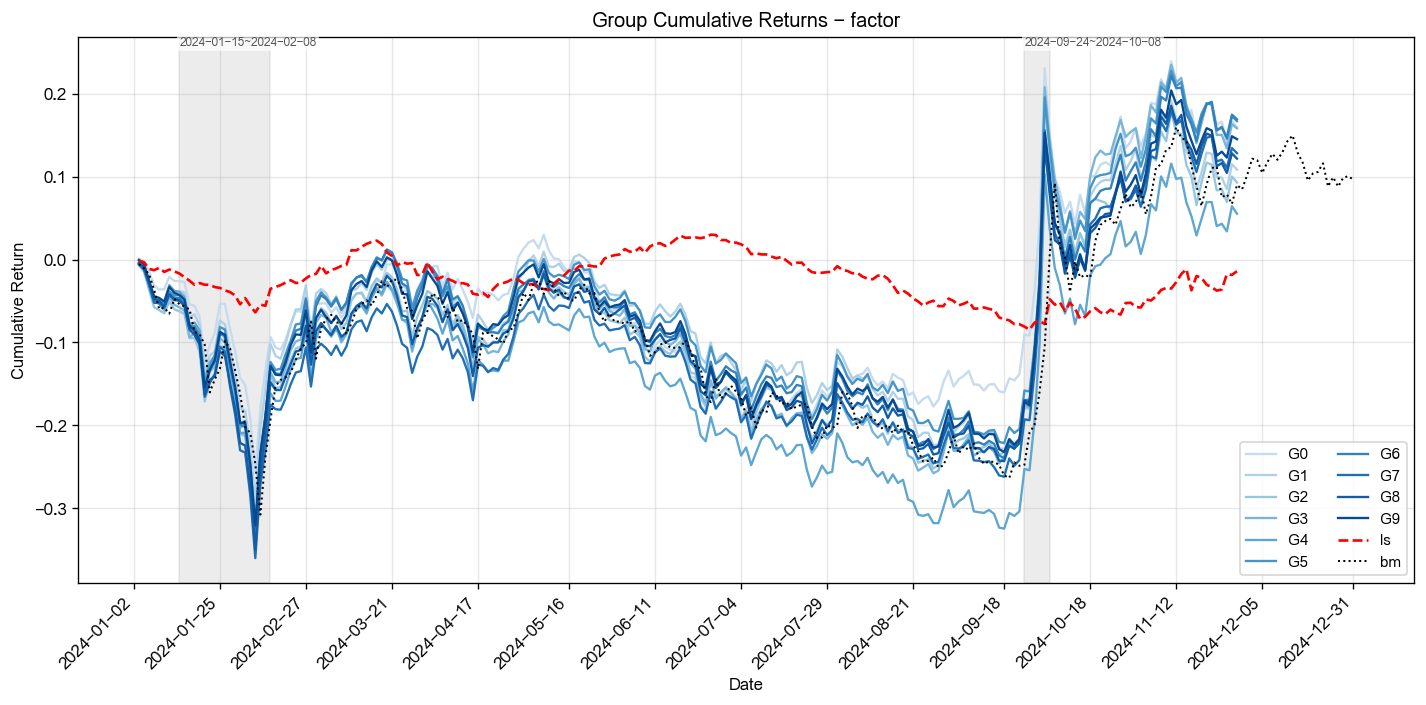
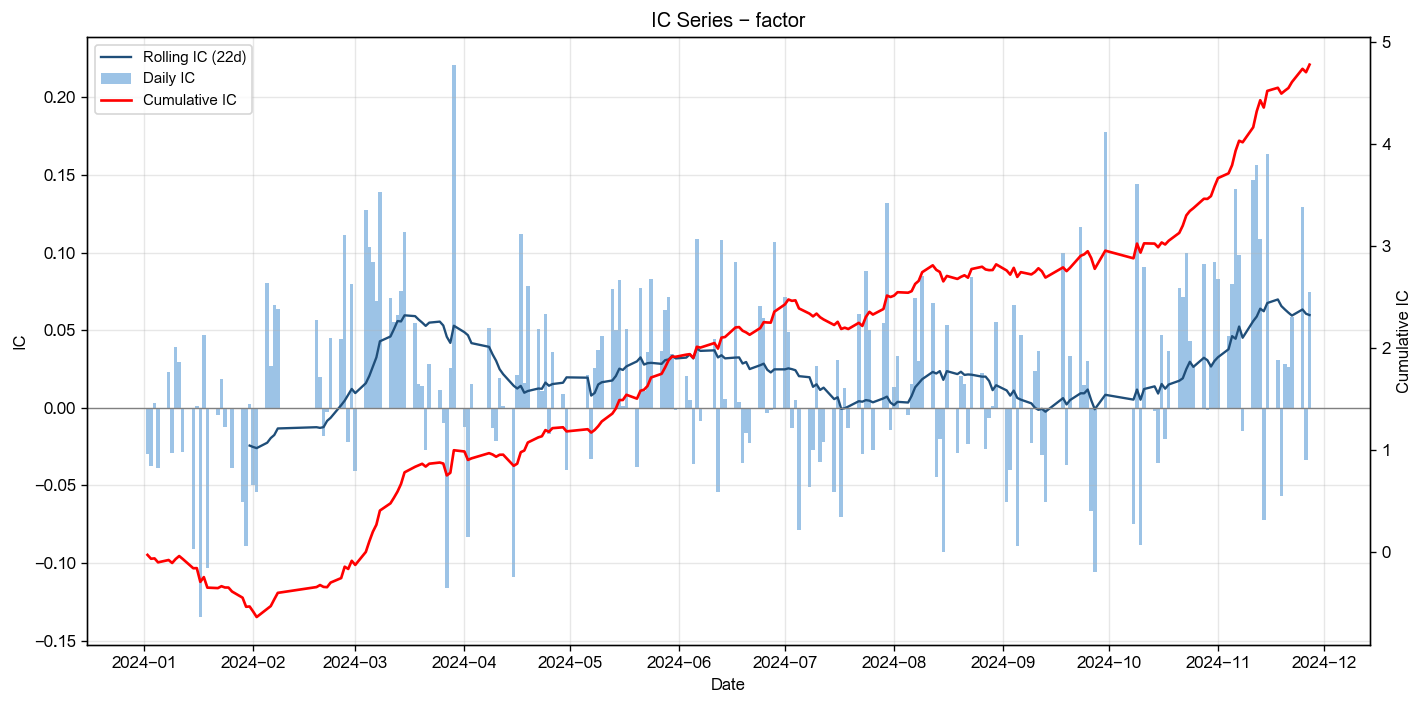
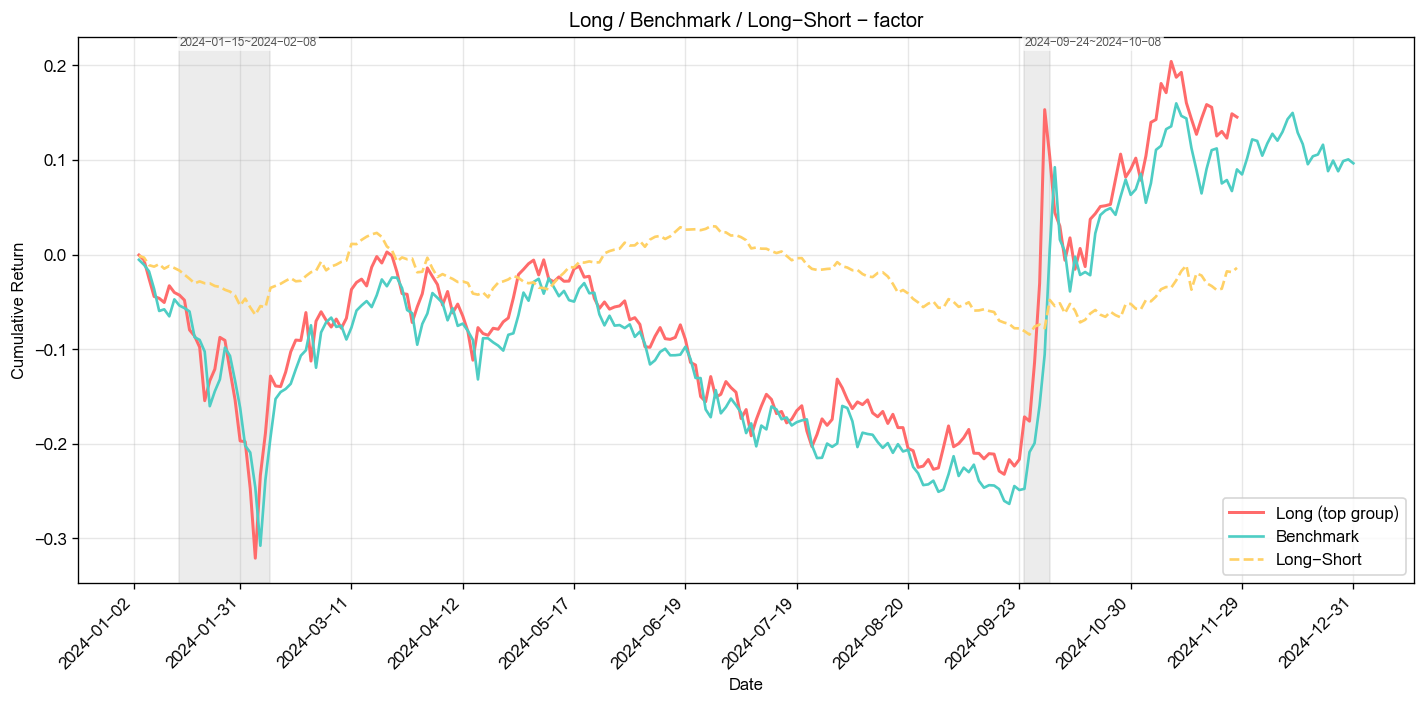
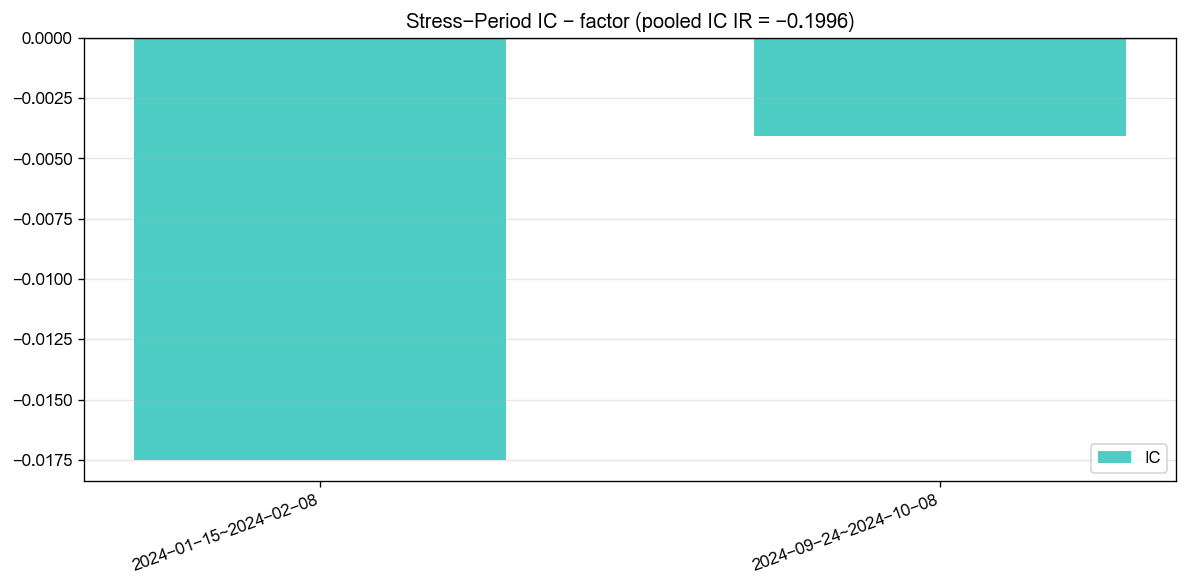
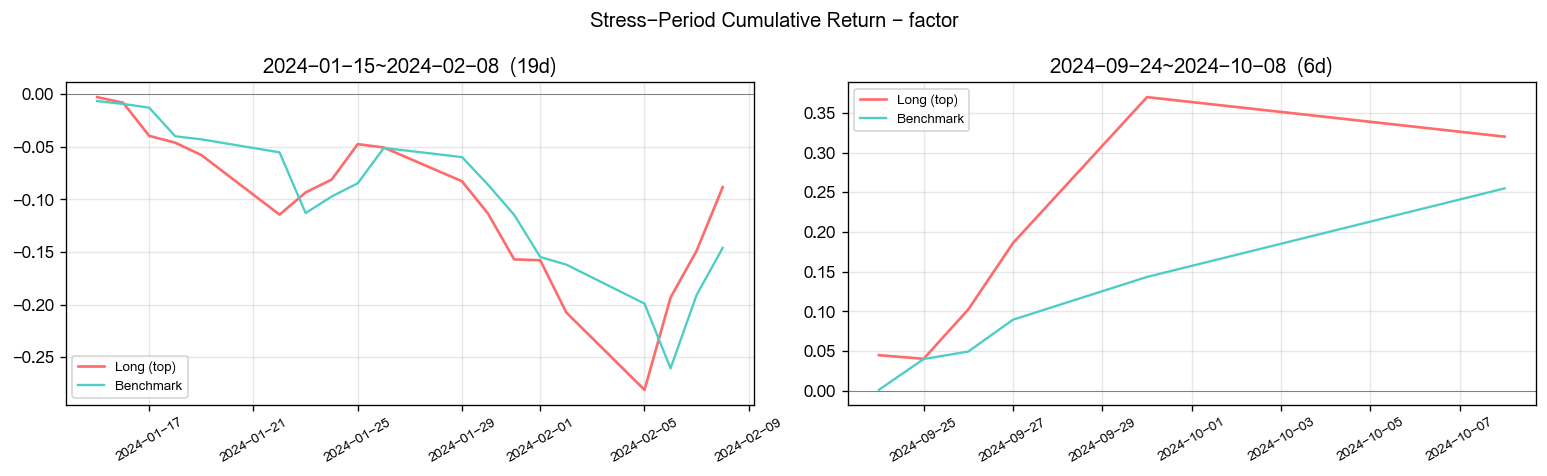

[2026-07-31 10:36:00] [info     ] ========== 因子池回归 ==========
[2026-07-31 10:36:00] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1206 rows=297953 start_date=2024-01-02
[2026-07-31 10:36:02] [info     ] 获取收益率数据, 耗时: 1.8629 秒
[2026-07-31 10:36:03] [info     ] 滚动 Elastic Net 拟合, 耗时: 1.001 秒
[2026-07-31 10:36:03] [info     ] 统计 回归结果, 耗时: 0.0081 秒


In [1]:
def main(datasources, start_date, end_date):
    import time
    import gc
    import numpy as np
    import pandas as pd
    import dai
    import structlog
    import xgboost as xgb

    logger = structlog.get_logger()
    t0 = time.time()

    # ==========================================
    # 全局配置
    # ==========================================
    USE_MINUTE_FLOW = True          # 分钟级资金流特征开关；若 Notebook 接近 3 小时上限可置 False 降级
    TRAIN_START    = "2021-06-01"   # 训练样本起点
    FIN_SEEN_BUFFER_DAYS = 150      # 财务查询相对训练起点的前置缓冲（自然日）：用于 PIT 表
    ASOF_TOL_DAYS  = 200            # 财务信息最长外推天数，超过则视为陈旧、落中性值
    DECAY_TAU      = 45             # 公告后信息衰减常数（自然日，约 30 个交易日）
    VAL_DAYS       = 60             # 验证集长度（交易日）
    PURGE_GAP_DAYS = 10             # 训练/验证之间 purge 间隔（自然日，覆盖 5 日 label 重叠）
    HALF_LIFE_DAYS = 365            # 训练样本时间衰减半衰期（自然日）

    fin_table   = datasources['financial']
    bar1m_table = datasources['bar1m']


    # ==========================================
    # 第一步：从平台 PIT 财务宽表按 shift/category 透视提取
    # ==========================================
    logger.info("1. 从 PIT 财务宽表按 shift/category 透视提取数据...")

    fin_seen_start = (
        pd.to_datetime(TRAIN_START) - pd.Timedelta(days=FIN_SEEN_BUFFER_DAYS)
    ).strftime('%Y-%m-%d')

    # SUE/SUR 需要 8 组同比差分 → mrq 需要 shift 0..11；其余口径按特征需求最小化选取
    pivot_terms = []
    for j in range(12):
        pivot_terms.append(
            f"MAX(CASE WHEN category='mrq' AND shift={j} THEN "
            f"COALESCE(net_profit_to_parent_deducted, net_profit) END) AS p_q{j}"
        )
        pivot_terms.append(
            f"MAX(CASE WHEN category='mrq' AND shift={j} THEN operating_revenue END) AS rev_q{j}"
        )
    for j in range(5):
        pivot_terms.append(
            f"MAX(CASE WHEN category='mrq' AND shift={j} THEN gross_profit END) AS gp_q{j}"
        )
    for j in (0, 4):
        pivot_terms.append(
            f"MAX(CASE WHEN category='mrq' AND shift={j} THEN net_cffoa END) AS cffoa_q{j}"
        )
        pivot_terms.append(
            f"MAX(CASE WHEN category='mrq' AND shift={j} THEN research_and_development_expense END) AS rd_q{j}"
        )
        pivot_terms.append(
            f"MAX(CASE WHEN category='ttm' AND shift={j} THEN nopat END) AS nopat_ttm{j}"
        )
        pivot_terms.append(
            f"MAX(CASE WHEN category='lf' AND shift={j} THEN invested_capital END) AS ic{j}"
        )
    pivot_terms += [
        "MAX(CASE WHEN category='ttm' AND shift=0 THEN fcff END) AS fcff_ttm0",
        "MAX(CASE WHEN category='ttm' AND shift=0 THEN operating_revenue END) AS rev_ttm0",
        "MAX(CASE WHEN category='lf' AND shift=0 THEN total_assets END) AS ta0",
        "MAX(CASE WHEN category='lf' AND shift=0 THEN interest_bearing_debt END) AS ibd0",
        "MAX(CASE WHEN category='lf' AND shift=0 THEN contract_liabilities END) AS cl0",
        "MAX(CASE WHEN category='lf' AND shift=1 THEN contract_liabilities END) AS cl1",
        "MAX(CASE WHEN category='lf' AND shift=0 THEN inventories END) AS inv0",
        "MAX(CASE WHEN category='lf' AND shift=1 THEN inventories END) AS inv1",
        "MAX(CASE WHEN shift=0 THEN report_date END) AS rd0",
    ]
    sql_fin = f"""
    SELECT date_trunc('day', date)::DATE AS date, instrument,
           {', '.join(pivot_terms)}
    FROM {fin_table}
    WHERE shift <= 11 AND date >= '{fin_seen_start}' AND date <= '{end_date}'
    GROUP BY date_trunc('day', date)::DATE, instrument
    """
    df_fin = dai.query(sql_fin, filters={'date': [fin_seen_start, end_date]}, compression=True).df()
    df_fin['date'] = pd.to_datetime(df_fin['date'])
    df_fin['instrument'] = df_fin['instrument'].astype(str)
    df_fin['rd0'] = pd.to_datetime(df_fin['rd0'])

    num_cols = [c for c in df_fin.columns if c not in ('date', 'instrument', 'rd0')]
    for c in num_cols:
        # float32 降精度：日频×全市场×~45 列的透视宽表体量较大，控制内存
        df_fin[c] = pd.to_numeric(df_fin[c], errors='coerce').astype(np.float32)

    # ==========================================
    # 第二步：公告新鲜度代理
    # ==========================================
    logger.info("2. 由 PIT 表推导报告期首次出现日（公告新鲜度代理）...")
    # shift=0 的 report_date 在 PIT 表中首次出现的日期 = 该报告在平台口径下首次可用之日，
    # 以此作为公告日代理来驱动时间衰减；推导只用允许表自身的历史行，无任何前视。
    # 前置缓冲期的数据仅用于该探测，探测完成后即裁掉，不进入训练/测试。
    df_fin = df_fin.sort_values(['instrument', 'date']).reset_index(drop=True)
    df_fin['ann_date'] = df_fin.groupby(['instrument', 'rd0'])['date'].transform('min')
    df_fin['days_since'] = (df_fin['date'] - df_fin['ann_date']).dt.days.astype(np.float32)
    df_fin = df_fin[df_fin['date'] >= pd.to_datetime(TRAIN_START)].reset_index(drop=True)

    # ==========================================
    # 第三步：财务特征构建（惊喜量 / 变化量 / 质量修正量，
    # ==========================================
    logger.info("3. 构建财务特征：SUE/SUR 惊喜、基本面动量、质量修正...")

    # --- 第 1 层：盈余/营收/毛利率惊喜（事件驱动核心）---
    # SUE：最新单季同比增量 / 过去 8 组同比增量的标准差；
    # shift 索引天然按季度对齐（shift j 与 shift j+4 即同比），无需日期间隔校验
    p_diffs = pd.DataFrame({j: df_fin[f'p_q{j}'] - df_fin[f'p_q{j+4}'] for j in range(8)})
    r_diffs = pd.DataFrame({j: df_fin[f'rev_q{j}'] - df_fin[f'rev_q{j+4}'] for j in range(8)})
    p_std = p_diffs.std(axis=1, ddof=1).replace(0, np.nan)
    r_std = r_diffs.std(axis=1, ddof=1).replace(0, np.nan)
    p_cnt = p_diffs.notna().sum(axis=1)
    r_cnt = r_diffs.notna().sum(axis=1)
    df_fin['sue'] = (p_diffs[0] / p_std).where(p_cnt >= 6)
    df_fin['sur'] = (r_diffs[0] / r_std).where(r_cnt >= 6)
    del p_diffs, r_diffs
    gc.collect()

    gm = pd.DataFrame({
        j: df_fin[f'gp_q{j}'] / df_fin[f'rev_q{j}'].replace(0, np.nan) for j in range(5)
    })
    gm_hist = gm[[1, 2, 3, 4]].mean(axis=1)
    gm_cnt = gm[[1, 2, 3, 4]].notna().sum(axis=1)
    df_fin['gm_surprise'] = (gm[0] - gm_hist).where(gm_cnt >= 2)
    del gm

    # --- 第 2 层：基本面动量（变化量而非水平值，避开 BARRA 风格空间）---
    df_fin['roic_chg'] = (
        df_fin['nopat_ttm0'] / df_fin['ic0'].replace(0, np.nan)
        - df_fin['nopat_ttm4'] / df_fin['ic4'].replace(0, np.nan)
    )
    df_fin['cf_cover_chg'] = (
        df_fin['cffoa_q0'] / df_fin['rev_q0'].replace(0, np.nan)
        - df_fin['cffoa_q4'] / df_fin['rev_q4'].replace(0, np.nan)
    )
    df_fin['rd_chg'] = (
        df_fin['rd_q0'] / df_fin['rev_q0'].replace(0, np.nan)
        - df_fin['rd_q4'] / df_fin['rev_q4'].replace(0, np.nan)
    )

    # --- 第 3 层：质量修正 + 保留的估值锚 ---
    ta = df_fin['ta0'].replace(0, np.nan)
    df_fin['accrual'] = (df_fin['p_q0'] - df_fin['cffoa_q0']) / ta
    df_fin['fcff_yield'] = df_fin['fcff_ttm0'] / ta
    df_fin['debt_ratio'] = df_fin['ibd0'] / ta
    df_fin['contract_chg'] = (
        (df_fin['cl0'] - df_fin['cl1']) / df_fin['rev_ttm0'].replace(0, np.nan)
    )
    df_fin['inv_chg'] = (df_fin['inv0'] - df_fin['inv1']) / ta

    FIN_FEATS = [
        'sue', 'sur', 'gm_surprise',
        'roic_chg', 'cf_cover_chg', 'rd_chg',
        'accrual', 'fcff_yield', 'debt_ratio', 'contract_chg', 'inv_chg',
    ]

    # 陈旧信息处理（替代旧版 merge_asof 的 tolerance）：最新报告首次出现距今超过
    # ASOF_TOL_DAYS 天仍未更新的（长期停牌/延迟披露），财务特征置空、rank 后落中性值
    stale = df_fin['days_since'] > ASOF_TOL_DAYS
    df_fin.loc[stale, FIN_FEATS] = np.nan

    df_fin = df_fin[['date', 'instrument', 'days_since'] + FIN_FEATS].copy()
    gc.collect()

    # ==========================================
    # 第四步：日频行情 + 因子库 + 短周期 Label
    # ==========================================
    logger.info("4. 提取日频行情，构建隔夜/日内分解与 1-3-5 日复合 Label...")

    sql_bar1d = f"""
    SELECT date_trunc('day', date)::DATE AS date, instrument,
           open, close, pre_close
    FROM bigalpha_2026_bar1d
    WHERE date >= '{TRAIN_START}' AND date <= '{end_date}'
    """
    df_px = dai.query(sql_bar1d, filters={'date': [TRAIN_START, end_date]}, compression=True).df()
    df_px['date'] = pd.to_datetime(df_px['date'])
    df_px['instrument'] = df_px['instrument'].astype(str)
    df_px = df_px.sort_values(['instrument', 'date']).reset_index(drop=True)

    g = df_px.groupby('instrument')
    # 隔夜/日内收益分解：隔夜反映情绪与外盘，日内反映真实交易行为，含义不同分开喂
    df_px['overnight_ret'] = df_px['open'] / df_px['pre_close'] - 1
    df_px['intraday_ret'] = df_px['close'] / df_px['open'] - 1
    df_px['ret5'] = df_px['close'] / g['close'].shift(5) - 1

    # 短周期 Label：1/3/5 日前瞻收益，逐期做市场中位数中性化后按 horizon 归一平均
    for n in (1, 3, 5):
        df_px[f'fr{n}'] = g['close'].shift(-n) / df_px['close'] - 1
    for n in (1, 3, 5):
        med = df_px.groupby('date')[f'fr{n}'].transform('median')
        df_px[f'nfr{n}'] = df_px[f'fr{n}'] - med
    df_px['label_raw'] = (
        df_px['nfr1'] / 1 + df_px['nfr3'] / 3 + df_px['nfr5'] / 5
    ) / 3.0
    # Label 截面 rank 化 —— 与比赛 Spearman IC 评分口径对齐，
    # 抗极端值，并拉平不同波动 regime 下的 label 尺度（防止极端行情样本主导 MSE）
    df_px['label'] = df_px.groupby('date')['label_raw'].rank(pct=True)

    df_px = df_px[['date', 'instrument', 'overnight_ret', 'intraday_ret',
                   'ret5', 'label']].copy()

    sql_market = f"""
    SELECT date_trunc('day', date)::DATE AS date, instrument,
           pb, ps_ttm, volatility_5, turn, momentum_5, beta_000300SH_22
    FROM bigalpha_2026_factorlib
    WHERE date >= '{TRAIN_START}' AND date <= '{end_date}'
    """
    df_market = dai.query(sql_market, filters={'date': [TRAIN_START, end_date]}, compression=True).df()
    df_market['date'] = pd.to_datetime(df_market['date'])
    df_market['instrument'] = df_market['instrument'].astype(str)

    df_mkt = pd.merge(df_px, df_market, on=['date', 'instrument'], how='left')
    del df_px, df_market
    gc.collect()

    # ==========================================
    # 第五步（数据库不可用）：分钟级主动资金流（DB 端聚合为日频，控制数据体量）
    # ==========================================
    # if USE_MINUTE_FLOW and bar1m_table:
    #     logger.info("5. 聚合分钟级主动买卖资金流...")
    #     sql_flow = f"""
    #     SELECT date_trunc('day', date)::DATE AS date, instrument,
    #            SUM(initiative_bid_amount) AS ibuy_amt,
    #            SUM(initiative_ask_amount) AS isell_amt,
    #            SUM(amount) AS day_amt
    #     FROM {bar1m_table}
    #     WHERE date >= '{TRAIN_START}' AND date <= '{end_date}'
    #     GROUP BY date_trunc('day', date)::DATE, instrument
    #     """
    #     df_flow = dai.query(sql_flow, filters={'date': [TRAIN_START, end_date]}, compression=True).df()
    #     df_flow['date'] = pd.to_datetime(df_flow['date'])
    #     df_flow['instrument'] = df_flow['instrument'].astype(str)
    #     for c in ['ibuy_amt', 'isell_amt', 'day_amt']:
    #         df_flow[c] = pd.to_numeric(df_flow[c], errors='coerce').astype(float)
    #     df_flow['flow'] = (
    #         (df_flow['ibuy_amt'] - df_flow['isell_amt'])
    #         / df_flow['day_amt'].replace(0, np.nan)
    #     )
    #     df_flow = df_flow.sort_values(['instrument', 'date'])
    #     df_flow['flow5'] = (
    #         df_flow.groupby('instrument')['flow']
    #         .transform(lambda s: s.rolling(5, min_periods=3).mean())
    #     )
    #     df_mkt = pd.merge(
    #         df_mkt, df_flow[['date', 'instrument', 'flow5']],
    #         on=['date', 'instrument'], how='left'
    #     )
    #     del df_flow
    #     gc.collect()
    # else:
    df_mkt['flow5'] = np.nan

    # ==========================================
    # 第六步：ASOF 融合 + 公告衰减 + 截面标准化 + 交互特征
    # ==========================================
    logger.info("6. 按 (date, instrument) 精确对齐 PIT 财务特征，构建公告衰减与交互特征...")
    # 按 (date, instrument) 精确左连接；
    df_ml = pd.merge(df_mkt, df_fin, on=['date', 'instrument'], how='left')
    del df_mkt, df_fin
    gc.collect()

    # 公告后时间衰减 —— 给季度更新的财务信息装上日度时间轴，使因子值逐日变化（日度 IC 的载体），信息随时间自然退出避免陈旧信号积累负 IC
    # days_since 由 PIT 表"报告期首次出现日"因果推导，见第二步
    df_ml['ann_decay'] = np.exp(-df_ml['days_since'].clip(lower=0) / DECAY_TAU).fillna(0.0)
    df_ml['days_norm'] = (df_ml['days_since'] / ASOF_TOL_DAYS).clip(0, 1).fillna(1.0)

    FIN_FEATS = [
        'sue', 'sur', 'gm_surprise',
        'roic_chg', 'cf_cover_chg', 'rd_chg',
        'accrual', 'fcff_yield', 'debt_ratio', 'contract_chg', 'inv_chg',
    ]
    MKT_FEATS = [
        'overnight_ret', 'intraday_ret', 'ret5', 'flow5',
        'pb', 'ps_ttm', 'volatility_5', 'turn', 'momentum_5', 'beta_000300SH_22',
    ]
    RANK_COLS = FIN_FEATS + MKT_FEATS

    df_ml['label'] = pd.to_numeric(df_ml['label'], errors='coerce').astype(float)
    for col in RANK_COLS:
        df_ml[col] = pd.to_numeric(df_ml[col], errors='coerce').astype(float)
        df_ml[col] = df_ml[col].replace([np.inf, -np.inf], np.nan)
        df_ml[col] = df_ml.groupby('date')[col].rank(pct=True)
        df_ml[col] = df_ml[col].fillna(0.5)

    # 显式交互特征 —— 强正则下树模型难以自发学到高阶交互，显式构造：
    # (a) 惊喜 × 公告衰减：PEAD 事件驱动主信号
    df_ml['sue_eff'] = df_ml['sue'] * df_ml['ann_decay']
    df_ml['sur_eff'] = df_ml['sur'] * df_ml['ann_decay']
    df_ml['gm_eff'] = df_ml['gm_surprise'] * df_ml['ann_decay']
    # (b) 惊喜 × 短期超跌：公告后正惊喜但被砸 = 错杀回补
    df_ml['sue_x_rev'] = df_ml['sue'] * (1.0 - df_ml['ret5'])
    # (c) 质量条件反转：高质量(盈利改善+低应计)股票的下跌更可能是流动性错杀
    df_ml['quality'] = 0.5 * df_ml['roic_chg'] + 0.5 * (1.0 - df_ml['accrual'])
    df_ml['qual_x_rev'] = df_ml['quality'] * (1.0 - df_ml['ret5'])
    df_ml['qual_x_intra'] = df_ml['quality'] * (1.0 - df_ml['intraday_ret'])
    # (d) 低估 × 聪明钱确认：DCF 均值回归的催化剂触发
    df_ml['value_x_flow'] = df_ml['fcff_yield'] * df_ml['flow5']

    INTER_FEATS = [
        'sue_eff', 'sur_eff', 'gm_eff', 'sue_x_rev',
        'quality', 'qual_x_rev', 'qual_x_intra', 'value_x_flow',
    ]
    feature_cols = RANK_COLS + ['ann_decay', 'days_norm'] + INTER_FEATS

    # ==========================================
    # 第七步：Purged 时序切分 + 时间衰减加权 XGBoost
    # ==========================================
    logger.info("7. Purged 时序切分并训练 XGBoost...")
    start_ts = pd.to_datetime(start_date)
    end_ts = pd.to_datetime(end_date)

    all_dates = np.sort(df_ml.loc[df_ml['date'] < start_ts, 'date'].unique())
    if len(all_dates) <= VAL_DAYS + 30:
        raise ValueError("训练期交易日不足，请检查 TRAIN_START 配置")
    val_start = pd.Timestamp(all_dates[-VAL_DAYS])
    # Purged 切分 —— 训练集尾部与验证集之间留出覆盖 label 前瞻窗口的空隙，
    # 阻断 5 日重叠 label 造成的训练→验证信息泄漏
    train_end = val_start - pd.Timedelta(days=PURGE_GAP_DAYS)

    train_mask = df_ml['date'] < train_end
    val_mask = (df_ml['date'] >= val_start) & (df_ml['date'] < start_ts)
    test_mask = (df_ml['date'] >= start_ts) & (df_ml['date'] <= end_ts)

    train_df = df_ml[train_mask].dropna(subset=['label']).copy()
    val_df = df_ml[val_mask].dropna(subset=['label']).copy()
    test_df = df_ml[test_mask].copy()
    del df_ml
    gc.collect()

    # 样本时间衰减加权 —— 缓解 2021-2023 与测试期的 regime 断裂，近期样本权重高（半衰期约 1 年），不丢弃旧数据、只降权
    ref_date = train_df['date'].max()
    w_train = np.power(
        0.5, (ref_date - train_df['date']).dt.days / HALF_LIFE_DAYS
    ).astype(np.float32).values

    X_train = np.ascontiguousarray(train_df[feature_cols].values, dtype=np.float32)
    y_train = np.ascontiguousarray(train_df['label'].values, dtype=np.float32)
    X_val = np.ascontiguousarray(val_df[feature_cols].values, dtype=np.float32)
    y_val = np.ascontiguousarray(val_df['label'].values, dtype=np.float32)
    X_test = np.ascontiguousarray(test_df[feature_cols].values, dtype=np.float32)

    # 短周期 label 下的参数重定标 ——
    # label 从 50 天改为 1-5 日复合，样本重叠度骤降、有效样本量放大一个数量级：
    # 松绑正则(min_child_weight 100→30, lambda 30→8, alpha 10→2)避免磨平微弱短周期 alpha；
    # 深度 3→4 以承载 SUE×衰减×反转等三阶以上交互；
    # 树数量放大 + early stopping 由 purged 验证集决定实际复杂度
    xgb_params = {
        'n_estimators': 500,
        'max_depth': 4,
        'learning_rate': 0.05,
        'subsample': 0.6,
        'colsample_bytree': 0.7,
        'min_child_weight': 30,
        'reg_alpha': 2.0,
        'reg_lambda': 8.0,
        'tree_method': 'hist',
        'n_jobs': -1,
        'random_state': 42,
        'early_stopping_rounds': 50,
        'eval_metric': 'rmse',
    }
    model = xgb.XGBRegressor(**xgb_params)
    model.fit(
        X_train, y_train,
        sample_weight=w_train,
        eval_set=[(X_val, y_val)],
        verbose=False,
    )
    logger.info(f"early stopping 停在第 {model.best_iteration} 轮")

    importance_df = pd.DataFrame({
        'feature': feature_cols,
        'importance': model.feature_importances_,
    }).sort_values('importance', ascending=False)
    print("\n[XGBoost 短周期预测特征重要性]")
    print(importance_df.to_string())

    # ==========================================
    # 第八步：截面预测、停牌中性化与交卷对齐
    # ==========================================
    logger.info("8. 生成因子并对齐股票池...")
    test_df['pred'] = model.predict(X_test)
    test_df['factor'] = test_df.groupby('date')['pred'].rank(pct=True)

    stk_pool = dai.query(
        "SELECT date, instrument FROM bigalpha_2026_instruments",
        filters={'date': [start_date, end_date]},
    ).df()
    stk_pool['date'] = pd.to_datetime(stk_pool['date'])
    stk_pool['instrument'] = stk_pool['instrument'].astype(str)

    result = pd.merge(
        stk_pool, test_df[['date', 'instrument', 'factor']],
        on=['date', 'instrument'], how='left'
    )
    result['factor'] = result['factor'].fillna(0.5)

    logger.info(f"事件驱动财务因子计算完成，耗时: {round(time.time() - t0, 2)} 秒")
    return result[['date', 'instrument', 'factor']]


# ========================
# BigQuant的计算执行行
# ========================
if __name__ == '__main__':
    from bigmodule import M
    import dai
    import structlog
    import pandas as pd
    import numpy as np

    logger = structlog.get_logger()

    datasources = {
        'bar1m': 'bigalpha_2026_stock_bar1m',
        'financial': 'bigalpha_2026_financial',
    }
    start_date = '2024-01-01 00:00:00'
    end_date = '2024-12-31 23:59:59'

    factor_data = main(datasources, start_date, end_date)

    factor_pool = dai.query(
        "SELECT * FROM bigalpha_2026_factorlib",
        filters={'date': [start_date, end_date]},
    ).df()

    M.bigalpha_eval._latest(
        factor_data=factor_data,
        factor_pool=factor_pool,
        process_pools=False,
        show=True,
    )
